# Dashboard de Mantenimiento — BoeIoT

**Audiencia:** equipo de mantenimiento (diagnóstico de motores, detección de anomalías, identificación de vuelos sospechosos).

**Fuente:** capa Gold — tabla `flight_summary.parquet` (1 fila por vuelo, ~35 KPIs). Ver [`docs/gold_to_dashboard.md`](../../docs/gold_to_dashboard.md) para el esquema completo.

**Carga de datos:** el notebook usa `loaders.load_gold()` con fallback en cascada:
1. S3 (LocalStack) → `s3://dos-boeing-737-max-gold-layer/flight_summary.parquet`
2. Caché local → `data/gold/flight_summary.parquet`
3. Cómputo inline desde Silver (también con el mismo fallback)

De modo que el dashboard corre aunque LocalStack esté caído o aunque el equipo no haya ejecutado todavía `silver_to_gold_etl.py`.


In [ ]:
import sys
from pathlib import Path

# Resolve repo root by walking upward until we find the loaders module, so the
# notebook works regardless of where Jupyter was launched (repo root, src/,
# src/notebooks/, …).
NOTEBOOK_DIR = Path.cwd().resolve()
for _cand in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents):
    if (_cand / "src" / "scripts" / "loaders.py").exists():
        SCRIPTS_DIR = _cand / "src" / "scripts"
        break
else:
    raise RuntimeError(
        "Could not locate src/scripts/loaders.py from "
        f"{NOTEBOOK_DIR}. Launch jupyter from inside the repo."
    )
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from loaders import load_gold

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

df, source = load_gold()
print(f"Loaded {len(df)} flights, {df.shape[1]} KPIs from Gold (source = {source}).")
df.head()


## 1. Resumen de flota

Vista de un vistazo: cuántos vuelos hay, cuántas horas se han operado, salud media y volumen de anomalías. Las cifras en rojo marcan vuelos que requieren inspección.


In [2]:
total_flights = len(df)
total_hours = df["flight_duration_min"].sum() / 60
avg_health = df["engine_health_score"].mean()
total_anomalies = int(df["total_anomaly_count"].sum())
critical_flights = int((df["engine_health_score"] < 60).sum())

summary = pd.DataFrame({
    "Indicador": [
        "Vuelos analizados",
        "Horas totales de operación",
        "Health score promedio",
        "Anomalías totales detectadas",
        "Vuelos con score < 60 (alerta)",
    ],
    "Valor": [
        f"{total_flights:,}",
        f"{total_hours:,.1f} h",
        f"{avg_health:.1f} / 100",
        f"{total_anomalies:,}",
        f"{critical_flights}",
    ],
})
summary.style.hide(axis="index").set_properties(**{"font-size": "13pt"})


Indicador,Valor
Vuelos analizados,43
Horas totales de operación,64.5 h
Health score promedio,55.1 / 100
Anomalías totales detectadas,"45,483"
Vuelos con score < 60 (alerta),26


## 2. Top 10 vuelos críticos

Vuelos con el peor `engine_health_score`. Estos son candidatos prioritarios para inspección.
Score < 50 (rojo) indica problemas serios; score 50–70 (naranja) requiere seguimiento.


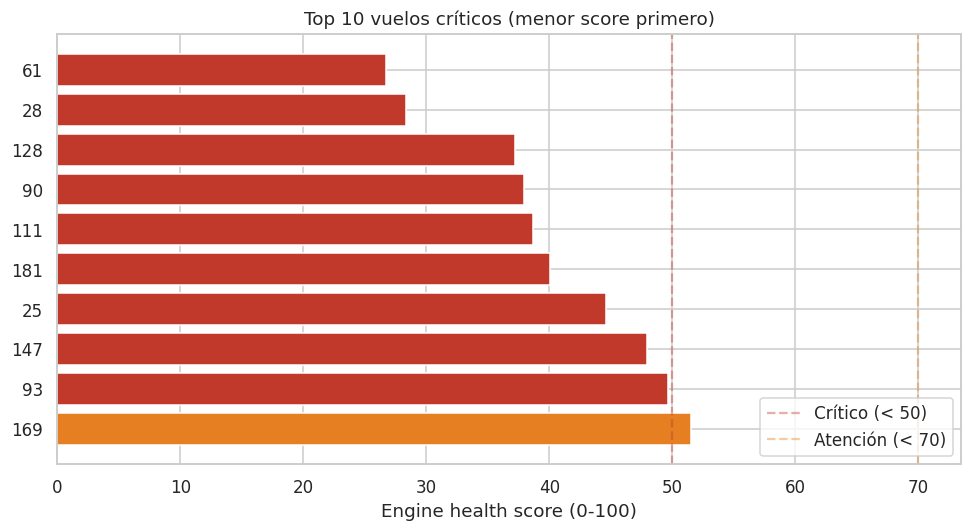

,flight_id,engine_health_score,total_anomaly_count,max_cht_spread,max_egt_spread
0,61,26.702701,5463,0.5400,0.415490
1,28,28.372472,6137,0.6350,0.227872
2,128,37.182221,2468,1.0000,0.450094
3,90,37.941604,2799,0.3375,1.000000
4,111,38.679427,2492,0.8350,0.523540
5,181,40.027703,3482,0.5500,0.288136
6,25,44.583749,1830,0.6650,0.400659
7,147,47.949462,452,0.4425,0.987759
8,93,49.680387,1462,0.5625,0.400188
9,169,51.519628,1421,0.4650,0.310264


In [3]:
top10 = df.nsmallest(10, "engine_health_score")[
    ["flight_id", "engine_health_score", "total_anomaly_count", "max_cht_spread", "max_egt_spread"]
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [
    "#c0392b" if s < 50 else "#e67e22" if s < 70 else "#27ae60"
    for s in top10["engine_health_score"]
]
ax.barh(top10["flight_id"].astype(str), top10["engine_health_score"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Engine health score (0-100)")
ax.set_title("Top 10 vuelos críticos (menor score primero)")
ax.axvline(50, color="#c0392b", linestyle="--", alpha=0.4, label="Crítico (< 50)")
ax.axvline(70, color="#e67e22", linestyle="--", alpha=0.4, label="Atención (< 70)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

top10


## 3. Distribución del Health Score

Distribución de la salud del motor en toda la flota. Las líneas verticales marcan los percentiles 10 y 25, definiendo umbrales de **crítico** y **atención** respectivamente.


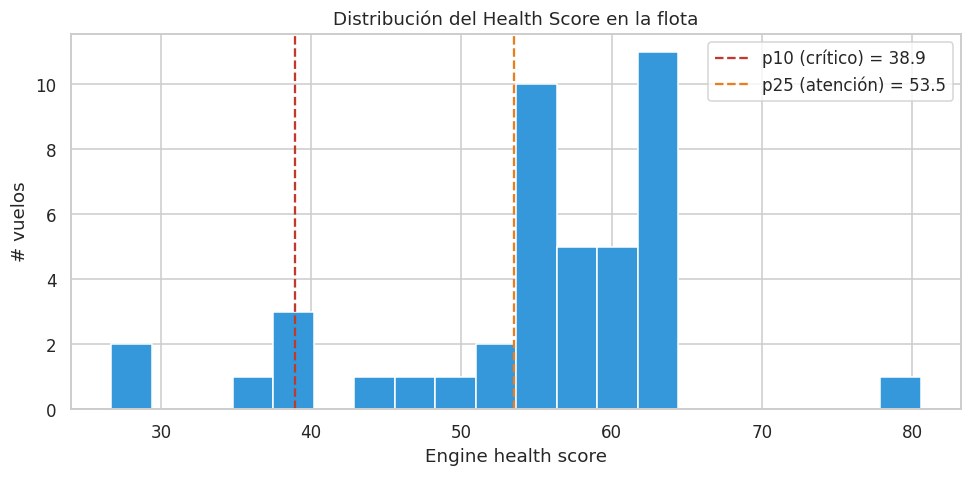

In [4]:
p10 = df["engine_health_score"].quantile(0.10)
p25 = df["engine_health_score"].quantile(0.25)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df["engine_health_score"], bins=20, color="#3498db", edgecolor="white")
ax.axvline(p10, color="#c0392b", linestyle="--", label=f"p10 (crítico) = {p10:.1f}")
ax.axvline(p25, color="#e67e22", linestyle="--", label=f"p25 (atención) = {p25:.1f}")
ax.set_xlabel("Engine health score")
ax.set_ylabel("# vuelos")
ax.set_title("Distribución del Health Score en la flota")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Mapa de calor de anomalías

Muestra los **top 30 vuelos** con más anomalías y la distribución de las mismas por tipo de evento. Permite ver patrones: ¿hay vuelos con problemas concentrados en un solo subsistema, o son problemas múltiples simultáneos?


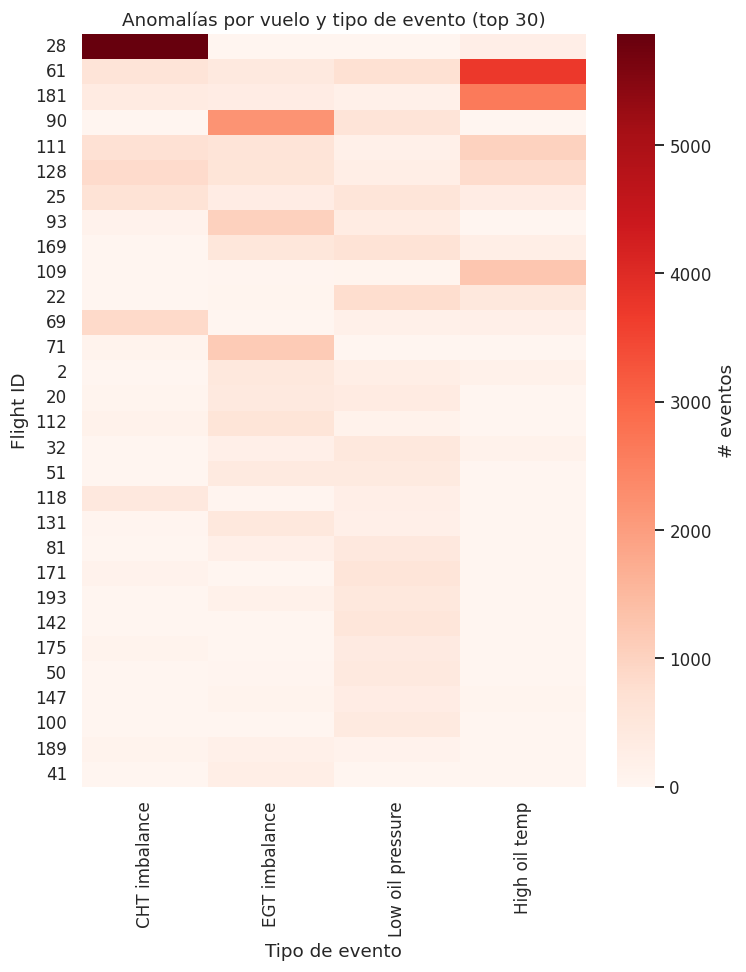

In [5]:
top30 = df.nlargest(30, "total_anomaly_count")
heatmap_data = top30.set_index("flight_id")[
    ["cht_imbalance_events", "egt_imbalance_events", "low_oil_pressure_events", "high_oil_temp_events"]
]
heatmap_data.columns = ["CHT imbalance", "EGT imbalance", "Low oil pressure", "High oil temp"]

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(heatmap_data, cmap="Reds", annot=False, cbar_kws={"label": "# eventos"}, ax=ax)
ax.set_title("Anomalías por vuelo y tipo de evento (top 30)")
ax.set_xlabel("Tipo de evento")
ax.set_ylabel("Flight ID")
plt.tight_layout()
plt.show()


## 5. Presión vs Temperatura de aceite

Cuadrante de riesgo: alta temperatura combinada con baja presión indica **falla inminente de lubricación**. El tamaño del punto refleja el conteo total de anomalías; el color, el health score (rojo = malo, verde = bueno).


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    df["avg_oil_temp"], df["min_oil_pressure"],
    s=20 + df["total_anomaly_count"] * 3,
    c=df["engine_health_score"], cmap="RdYlGn",
    alpha=0.75, edgecolor="black", linewidth=0.4,
)
# Highlight the danger quadrant: top quartile of avg_oil_temp + bottom quartile of min_oil_pressure
temp_p75 = df["avg_oil_temp"].quantile(0.75)
pres_p25 = df["min_oil_pressure"].quantile(0.25)
# Guard against a degenerate flat-pressure dataset where max == min would
# divide by zero and yield ymax = NaN/Inf, blanking the whole axis.
pres_min = df["min_oil_pressure"].min()
pres_range = df["min_oil_pressure"].max() - pres_min
ymax = (pres_p25 - pres_min) / pres_range if pres_range else 1.0
ax.axvspan(
    temp_p75, df["avg_oil_temp"].max(),
    ymax=ymax,
    color="red", alpha=0.08, label="Cuadrante peligroso",
)
ax.set_xlabel("Temperatura promedio de aceite (normalizada)")
ax.set_ylabel("Presión mínima de aceite (normalizada)")
ax.set_title("Riesgo de lubricación — Presión vs Temperatura de aceite")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Engine health score")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 6. Desbalance entre cilindros (CHT y EGT)

Spread = `max - min` entre los 4 cilindros del motor. Un spread alto indica que un cilindro opera fuera de sincronía (posible misfire, fuga de compresión o falla de inyector). Se segmenta por la **fase dominante** del vuelo para identificar si el problema aparece en alguna fase específica.


/tmp/ipykernel_597436/2643051872.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_597436/2643051872.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


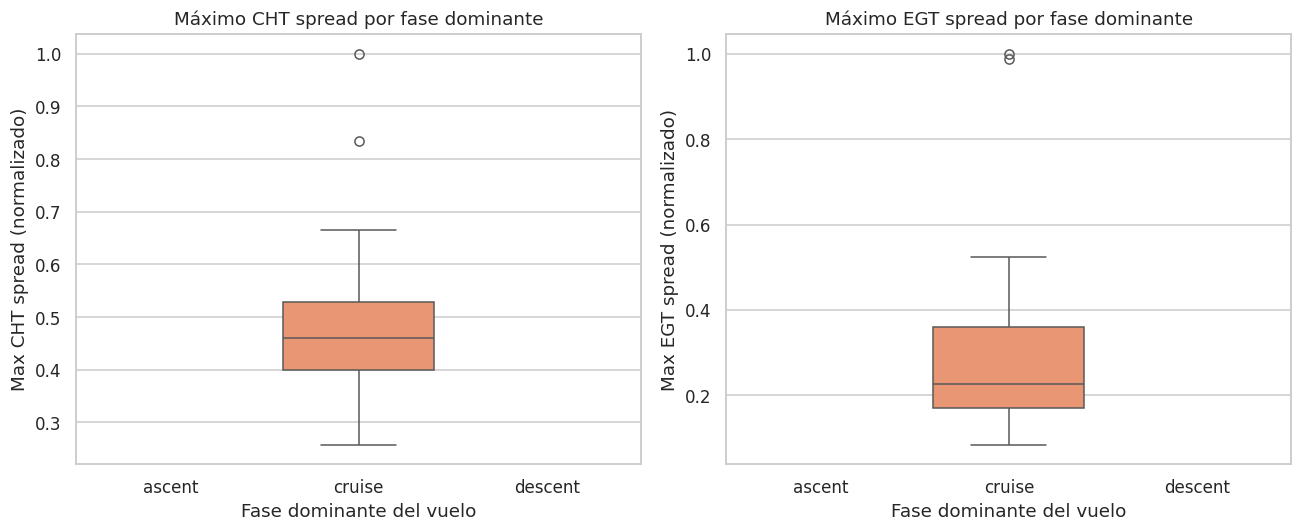

In [7]:
df = df.assign(
    dominant_phase=df[["pct_ascent", "pct_cruise", "pct_descent"]]
    .idxmax(axis=1)
    .str.replace("pct_", "", regex=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
sns.boxplot(
    data=df, x="dominant_phase", y="max_cht_spread",
    order=["ascent", "cruise", "descent"], ax=axes[0], palette="Set2",
)
axes[0].set_title("Máximo CHT spread por fase dominante")
axes[0].set_xlabel("Fase dominante del vuelo")
axes[0].set_ylabel("Max CHT spread (normalizado)")

sns.boxplot(
    data=df, x="dominant_phase", y="max_egt_spread",
    order=["ascent", "cruise", "descent"], ax=axes[1], palette="Set2",
)
axes[1].set_title("Máximo EGT spread por fase dominante")
axes[1].set_xlabel("Fase dominante del vuelo")
axes[1].set_ylabel("Max EGT spread (normalizado)")

plt.tight_layout()
plt.show()


## 7. Consumo de combustible

Vuelos ordenados por combustible consumido. Los vuelos con **alto desbalance entre tanques** (`max_fuel_imbalance` por encima del p75) se resaltan en naranja — esto puede indicar fuga, sensor defectuoso o transferencia asimétrica.


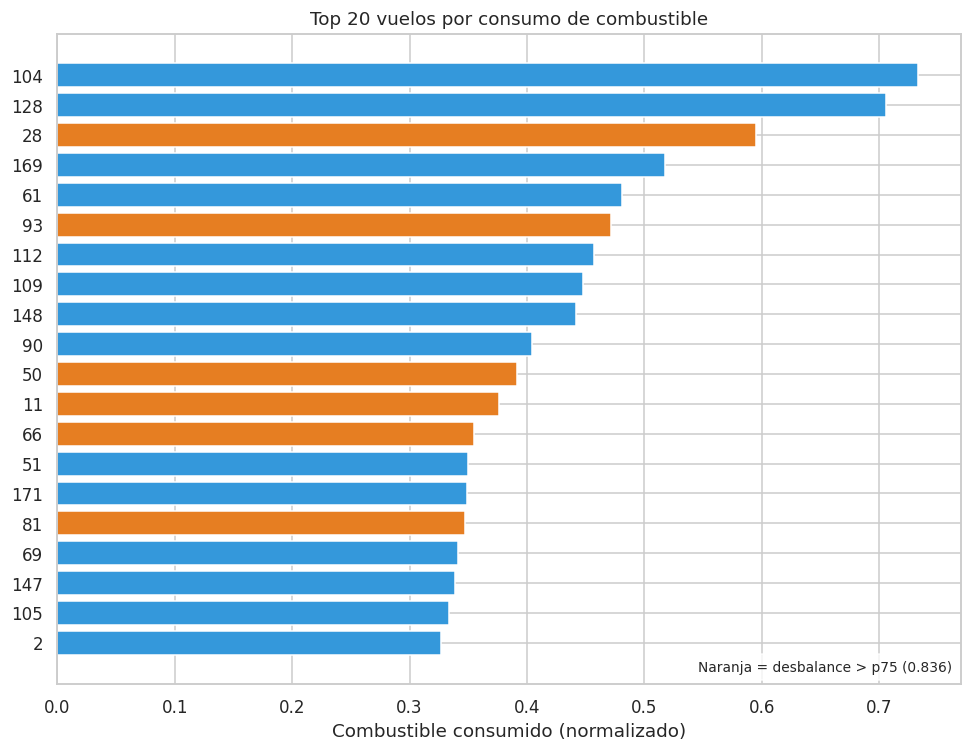

In [8]:
top_fuel = df.nlargest(20, "fuel_consumed").sort_values("fuel_consumed", ascending=True)
imbalance_threshold = df["max_fuel_imbalance"].quantile(0.75)
colors = [
    "#e67e22" if x > imbalance_threshold else "#3498db"
    for x in top_fuel["max_fuel_imbalance"]
]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_fuel["flight_id"].astype(str), top_fuel["fuel_consumed"], color=colors)
ax.set_xlabel("Combustible consumido (normalizado)")
ax.set_title("Top 20 vuelos por consumo de combustible")
ax.text(
    0.99, 0.02,
    f"Naranja = desbalance > p75 ({imbalance_threshold:.3f})",
    transform=ax.transAxes, ha="right", fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8),
)
plt.tight_layout()
plt.show()


## 8. Calidad de telemetría vs. Health score

Cruza la **disponibilidad de sensores** con el health score. Si hay correlación negativa fuerte (vuelos con datos degradados tienen scores bajos), parte del score puede ser un **falso positivo** causado por datos faltantes, no por problemas reales del motor.

Si los puntos están dispersos sin correlación clara, los problemas detectados son reales (independientes de la calidad del dato).


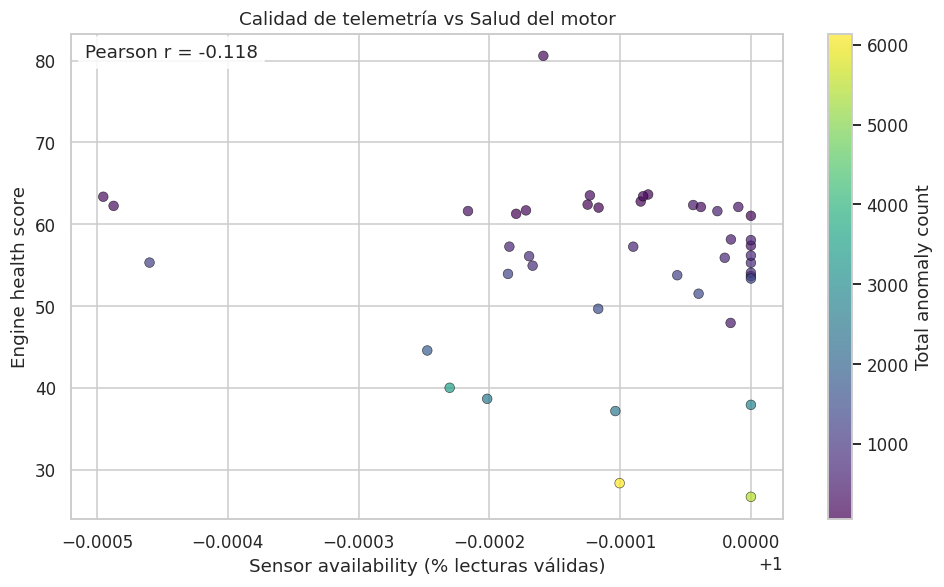

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(
    df["sensor_availability"], df["engine_health_score"],
    c=df["total_anomaly_count"], cmap="viridis", s=40, alpha=0.7,
    edgecolor="black", linewidth=0.4,
)
ax.set_xlabel("Sensor availability (% lecturas válidas)")
ax.set_ylabel("Engine health score")
ax.set_title("Calidad de telemetría vs Salud del motor")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Total anomaly count")

corr = df[["sensor_availability", "engine_health_score"]].corr().iloc[0, 1]
ax.text(
    0.02, 0.98,
    f"Pearson r = {corr:+.3f}",
    transform=ax.transAxes, va="top",
    bbox=dict(facecolor="white", alpha=0.85),
)
plt.tight_layout()
plt.show()


## 9. Drill-down: perfil temporal de un vuelo

Selecciona un vuelo crítico (peor health score) y muestra su perfil segundo-a-segundo de altitud, RPM, presión de aceite y spread de cilindros sobre la duración del vuelo. Permite a mantenimiento ver **cuándo** y **dónde** se concentran los eventos anómalos dentro del vuelo, en vez de solo el resumen agregado.

Esta sección lee desde Silver (no Gold) porque Gold ya está agregado por vuelo. Usa el mismo fallback S3 → local-cache.


In [ ]:
from loaders import load_silver

silver_df, silver_source = load_silver()
print(f"Silver cargado desde {silver_source}: {len(silver_df):,} filas.")

# Choose the worst flight by gold health score and pull its timeline from silver.
# Use seq_idx (the canonical chronological order key from bronze) when present,
# falling back to the dataframe index for backward compatibility.
if df.empty:
    raise RuntimeError(
        "Gold dataframe is empty — cannot drill into a worst flight. "
        "Re-run the ETL or check the Gold layer."
    )
worst_flight = df.nsmallest(1, "engine_health_score").iloc[0]["flight_id"]
flight_ts = silver_df[silver_df["flight_id"] == worst_flight].copy()
if "seq_idx" in flight_ts.columns:
    flight_ts = flight_ts.sort_values("seq_idx").reset_index(drop=True)
    flight_ts["t_sec"] = flight_ts["seq_idx"]
else:
    flight_ts = flight_ts.reset_index(drop=True)
    flight_ts["t_sec"] = flight_ts.index  # 1 Hz sampling per silver ETL

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(flight_ts["t_sec"], flight_ts["AltMSL"], color="#2c3e50")
axes[0].set_ylabel("Altitud (norm)")
axes[0].set_title(f"Perfil temporal del vuelo {worst_flight} (peor health score)")

axes[1].plot(flight_ts["t_sec"], flight_ts["E1_RPM"], color="#16a085")
axes[1].set_ylabel("RPM (norm)")

axes[2].plot(flight_ts["t_sec"], flight_ts["E1_OilP"], color="#2980b9", label="Oil pressure")
axes[2].plot(flight_ts["t_sec"], flight_ts["E1_OilT"], color="#c0392b", label="Oil temperature")
axes[2].set_ylabel("Aceite (norm)")
axes[2].legend(loc="upper right")

axes[3].plot(flight_ts["t_sec"], flight_ts["cht_spread"], color="#8e44ad", label="CHT spread")
axes[3].plot(flight_ts["t_sec"], flight_ts["egt_spread"], color="#d35400", label="EGT spread")
axes[3].set_ylabel("Spread (norm)")
axes[3].set_xlabel("Tiempo dentro del vuelo (s)")
axes[3].legend(loc="upper right")

plt.tight_layout()
plt.show()


---

## Cómo extender este dashboard

1. Agregar un nuevo KPI en `src/scripts/silver_to_gold_etl.py` (línea en `groupby().agg()` o cálculo derivado).
2. Re-ejecutar el pipeline: `uv run src/scripts/silver_to_gold_etl.py` (o reabrir este notebook — el fallback recomputa Gold inline si no está en S3).
3. Crear celda markdown + code aquí siguiendo el patrón de las secciones anteriores.
4. Documentar el nuevo KPI y su visualización en [`docs/gold_to_dashboard.md`](../../docs/gold_to_dashboard.md).
